Modified from "Using Deep Learning for Flexible and Scalable Earthquake Forecasting"  
Reference: [Zenodo](https://zenodo.org/records/8161777)

In [1]:
import sys
import pandas as pd
import numpy as np
from pathlib import Path
import torch
import src  
import matplotlib.pyplot as plt
from src.utils.utils import set_seed
import src.data.catalog as catalog
import src.catalogs as catalogs
import functools
import os
import importlib
sys.path.append(str(Path.cwd().parent))
os.environ["CUDA_LAUNCH_BLOCKING"] = "1"
set_seed(0) 

In [2]:
checkpoint_dir = Path("../checkpoints/mixer_tpp_20260207-095619") 
checkpoint_path = checkpoint_dir / "best_model_1.pth"

## Loading a trained model

In [3]:
from src.models.builders import ModelBuilder
from src.train.config_setup import load_args_from_checkpoint,load_model_from_checkpoint

check_point = torch.load(checkpoint_path,weights_only=False)    
args = load_args_from_checkpoint(None, check_point)
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
model_builder = ModelBuilder.by_name(args.model.lower())()
model = model_builder(args, device)
model,_,_ = load_model_from_checkpoint(model, check_point)
# model.set_attn_type("flash")
# model.set_attn_dropout(0)
model = torch.compile(model)
model.eval() 

MixerTPP context size: 64
load_specific_parts: None
Checkpoint loaded: <All keys matched successfully>
hyperparameters: {'resume_path': './checkpoints/mixer_tpp_20260203-161948/last_model_1.pth', 'load_specific_parts': ['encoder'], 'model': 'mixer_tpp', 'num_event_types': 1, 'pad_token_id': 1, 'task_type': 'tpp', 'batch_size': 1, 'accumulation_steps': 1, 'warmup_ratio': 0.1, 'learning_rate': 0.001, 'weight_decay': 0.01, 'scheduler_factor': None, 'scheduler_patience': None, 'scheduler_threshold': None, 'scheduler_min_lr': 1e-06, 'scheduler_type': 'step_warmup', 'step_lr_step_size_ratio': 0.2, 'step_lr_gamma': 0.8, 'dropout': 0.3, 'd_model': 64, 'mixer_model_config': {'input_dim': 1, 'dropout_prob': 0.1, 'd_model': 64, 'n_layer': 3, 'd_intermediate': 128, 'attn_layer_idx': [1], 'input_proj_type': 'mlp', 'input_proj_hidden': 128, 'input_proj_activation': 'silu', 'input_proj_dropout': 0.1, 'input_init': 'kaiming_uniform', 'input_init_scale': 1.5, 'ssm_cfg': {'layer': 'Mamba2Rotary', 'use_c

OptimizedModule(
  (_orig_mod): MixerTPP(
    (base_model): MixerModelWrapper(
      (encoder): MixerModel(
        (input_proj): Sequential(
          (0): Linear(in_features=1, out_features=128, bias=True)
          (1): SiLU()
          (2): Dropout(p=0.1, inplace=False)
          (3): Linear(in_features=128, out_features=64, bias=True)
        )
        (dropout): Dropout(p=0.1, inplace=False)
        (layers): ModuleList(
          (0): Block(
            (norm): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
            (mixer): Mamba2Rotary(
              (in_proj): Linear(in_features=64, out_features=514, bias=False)
              (act): SiLU()
              (norm): RMSNorm()
              (out_proj): Linear(in_features=128, out_features=64, bias=False)
              (rotary_emb): RotaryEmbeddingTime()
            )
            (dropout): Dropout(p=0.1, inplace=False)
            (norm2): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
            (mlp): GatedMLP(
  

In [4]:
# model.print_params()

## Loading the catalog

In [5]:
# args.dataset = "ChinaArray" 
catalog_ds_class = catalog.Catalog.by_name(f"{args.dataset}-Standard")
catalog_ds = catalog_ds_class(root_dir=f'../data/{args.dataset}/raw')

Loading existing catalog from /root/autodl-tmp/chuandian_eq/data/ChuanDian/raw.


In [6]:
catalog_ds.full_sequence

Sequence(
  inter_times: [11581],
  arrival_times: [11580],
  t_start: 0.0,
  t_end: 18771.0,
  t_nll_start: 0.0,
  mag: [11580],
  loc: [11580, 2],
  depth: [11580]
)

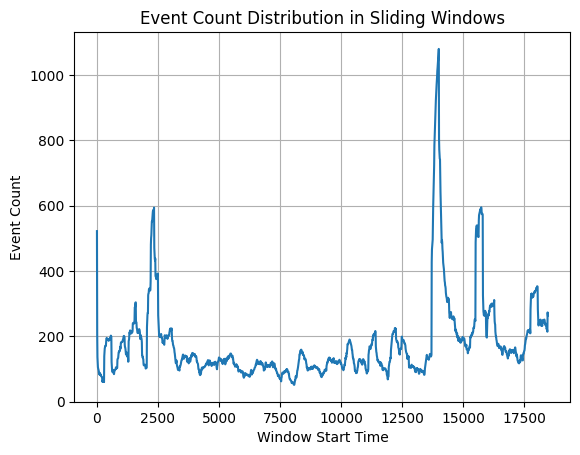

In [7]:
window_size = 300
stride = 10
arrival_times = catalog_ds.full_sequence.arrival_times
max_time = arrival_times.max().item()
window_starts = torch.arange(0, max_time - window_size + stride, stride)
counts = torch.zeros(len(window_starts), dtype=torch.int32)

for i, start in enumerate(window_starts):
    end = start + window_size
    mask = (arrival_times >= start) & (arrival_times < end)
    counts[i] = mask.sum()
plt.plot(window_starts, counts)
plt.xlabel('Window Start Time')
plt.ylabel('Event Count')
plt.title('Event Count Distribution in Sliding Windows')
plt.grid(True)
plt.show()

In [8]:
# b_seq = model.compute_b_value(catalog_ds.full_sequence.to(device),True)
# plt.plot(b_seq.squeeze().detach().cpu().numpy())
# plt.savefig(checkpoint_dir/'b_pred.png')
# data = b_seq.squeeze().detach().cpu().numpy()
# smooth = pd.Series(data).rolling(window=500, min_periods=1).mean()
# plt.plot(smooth)
# plt.savefig(checkpoint_dir/'b_pred_smooth.png')

## Prepare the data

We trained the TPP model using the `train` and `val` sequences. Now we will use the unseen section of the `test` sequence (in orange) to evaluate forecasting performance of the model.

<Axes: xlabel='Arrival time (days)', ylabel='Magnitude'>

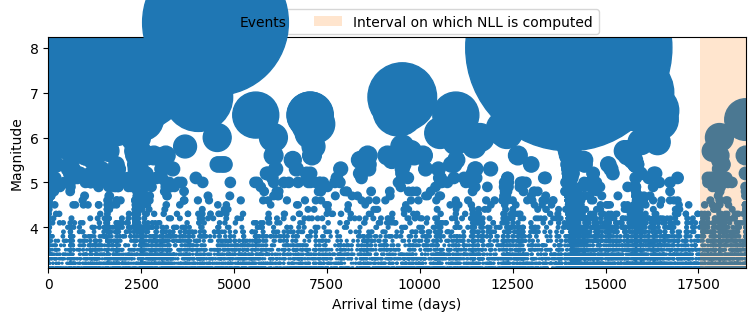

In [9]:
from src.utils.visualization import visualize_sequence
test_seq = catalog_ds.test[0]
train_seq = catalog_ds.train[0]
visualize_sequence(test_seq, show_nll=True)

We would like to generate a 30-day forecast for the interval `[13000, 13030]`. For this, we select two subsequences:
- `past_seq`: Contains events from `[0, 13000]`, is used to condition the model
- `observed_seq`: Contains actually observed events from `[13000, 13030]`.

In [10]:
t_forecast = 18000 #  13000
duration = 30 # 7 30
num_samples = 10000 # 10000

# Past events that we condition on
past_seq = test_seq.get_subsequence(0, t_forecast) #  3500
observed_seq = test_seq.get_subsequence(t_forecast, t_forecast + duration)

## Generate the forecast

In [11]:
past_seq.float()

Sequence(
  inter_times: [10837],
  arrival_times: [10836],
  t_start: 0.0,
  t_end: 18000.0,
  t_nll_start: 17532.0,
  mag: [10836],
  loc: [10836, 2],
  depth: [10836]
)

In [12]:
past_batch = src.data.Batch.from_list([past_seq])

In [13]:
torch.mean(past_batch.inter_times)

tensor(1.6610)

In [14]:
if torch.cuda.is_available():
    model.to('cuda:0')
    past_seq.to('cuda:0')

In [15]:
# torch.backends.cudnn.enabled = False

In [16]:
# model.print_params()
model.M_m = torch.tensor(10)

In [17]:
import torch
# model.richter_b = torch.tensor(1.01)

In [66]:
set_seed(0) 
model.eval()  # Set the model to evaluation mode

all_forecasts = []
samples_per_batch = 2000
for _ in range(num_samples // samples_per_batch):
    # forecast = model.sample_with_cache(batch_size=samples_per_batch, duration=duration, past_seq=past_seq, return_sequences=True)
    forecast = model.sample(batch_size=samples_per_batch, duration=duration, past_seq=past_seq, return_sequences=True, max_sample_len=6000,predict_b=True)
    # forecast = model.sample(batch_size=samples_per_batch, duration=duration, past_seq=past_seq, return_sequences=True)
    # forecast = model.sample_gpu_parallel(batch_size=samples_per_batch, duration=duration, past_seq=past_seq, return_sequences=True, dtype=torch.float32)
    all_forecasts.extend(forecast)

/root/autodl-tmp/chuandian_eq/src/data/sequence.py:246: UserWarning: Found 1 zero inter-event times in the sequence. This violates fundamental assumptions of TPP models and may lead to incorrect log-likelihood values.
  warnings.warn(


`forecast` is a list, where each element is a `eq.data.Sequence` that represents a possible continuation of the catalog over the interval `[13000, 13030]`.

With the following function, we
- visualize 10 randomly chosen trajectories as a counting process
- plot the distribution of the total # of events in the forecast interval

In [67]:
importlib.reload(src.utils.visualization)

<module 'src.utils.visualization' from '/root/autodl-tmp/chuandian_eq/src/utils/visualization.py'>

(<Figure size 1500x300 with 3 Axes>,
 (<Axes: title={'center': 'Observed Sequence and Example Forecast Trajectories'}, xlabel='Days since 1970-01-01', ylabel='Magnitude'>,
  <Axes: title={'center': 'Forecast counts'}, xlabel='Frequency', ylabel='Event count in window'>,
  <Axes: ylabel='Cumulative count'>))

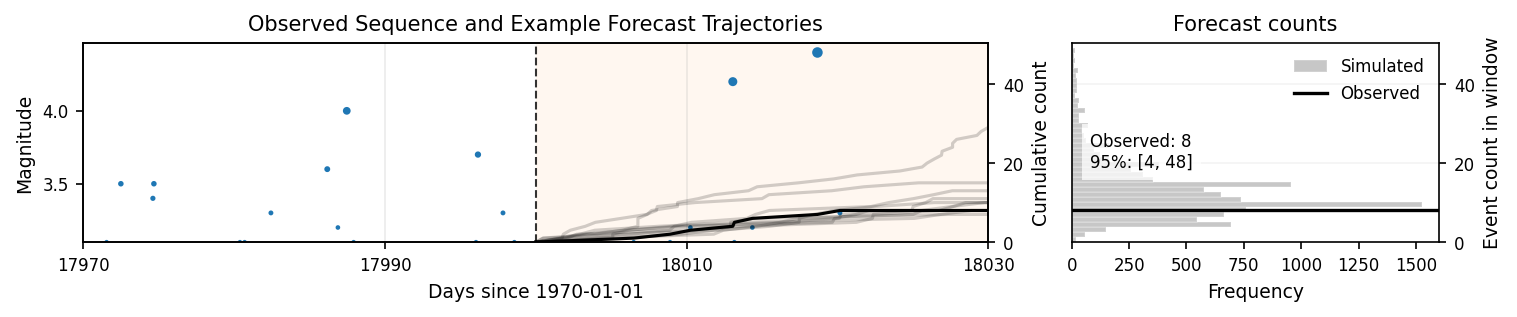

In [68]:
date_str = catalog_ds.metadata['start_ts'].strftime('%Y-%m-%d')
src.utils.visualization.visualize_trajectories(test_seq, all_forecasts,save_path=checkpoint_dir/"all_forecasts.pdf",figsize=(10,2),xlabel='Days since '+date_str,offset=10)
# src.utils.visualization.visualize_trajectories(train_seq, all_forecasts,save_path=checkpoint_dir/"all_forecasts.png")

N-test

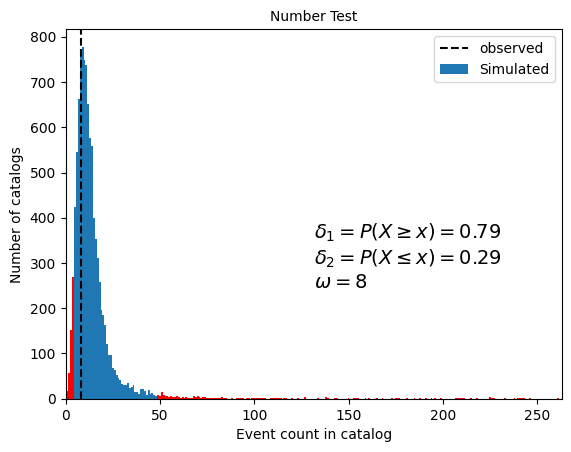

In [69]:
import  src.utils.catalog_tests as catalog_tests
number_test_result = catalog_tests.run_number_test_result(
    event_counts=[len(fc) for fc in all_forecasts],
    obs_count=len(observed_seq),                   
    min_mw=catalog_ds.metadata['mag_completeness'],
    obs_name='observed',
    sim_name='Simulated',
    plot=False
)
ax= number_test_result.plot(plot_args={'figsize':(6.4,4.8),'tight_layout':False})
plt.savefig(checkpoint_dir/'n_test.pdf')

In [70]:
all_forecasts

[Sequence(
   inter_times: [33],
   arrival_times: [32],
   t_start: 18000.0,
   t_end: 18030.0,
   t_nll_start: 18000.0,
   mag: [32]
 ),
 Sequence(
   inter_times: [11],
   arrival_times: [10],
   t_start: 18000.0,
   t_end: 18030.0,
   t_nll_start: 18000.0,
   mag: [10]
 ),
 Sequence(
   inter_times: [114],
   arrival_times: [113],
   t_start: 18000.0,
   t_end: 18030.0,
   t_nll_start: 18000.0,
   mag: [113]
 ),
 Sequence(
   inter_times: [7],
   arrival_times: [6],
   t_start: 18000.0,
   t_end: 18030.0,
   t_nll_start: 18000.0,
   mag: [6]
 ),
 Sequence(
   inter_times: [11],
   arrival_times: [10],
   t_start: 18000.0,
   t_end: 18030.0,
   t_nll_start: 18000.0,
   mag: [10]
 ),
 Sequence(
   inter_times: [9],
   arrival_times: [8],
   t_start: 18000.0,
   t_end: 18030.0,
   t_nll_start: 18000.0,
   mag: [8]
 ),
 Sequence(
   inter_times: [8],
   arrival_times: [7],
   t_start: 18000.0,
   t_end: 18030.0,
   t_nll_start: 18000.0,
   mag: [7]
 ),
 Sequence(
   inter_times: [9],
 

M-test

In [71]:
config_dict = {
    'min_mw': catalog_ds.metadata['mag_completeness'],
    'max_mw': 10,
    'dmw': 0.01
}

magnitude_bins, distribution = catalog_tests.compute_magnitude_distribution(
    forecast[0].mag.cpu().numpy(), 
   **config_dict
)

In [72]:
import numpy as np
import torch

def compute_b_mle(data, mmin, dmw=0.01):

    def _compute_from_mags(mags_t):
        sel = mags_t[mags_t >= mmin]
        n = int(sel.numel())
        if n == 0:
            raise ValueError("No magnitudes above or equal to mmin for b-value calculation.")
        mean_mag = float(sel.mean().item())
        b = 0.4342944819 / (mean_mag - (mmin - dmw / 2))  # log10(e)
        b_se = b / (n ** 0.5)
        return b, b_se, n, mean_mag

    # Normalize input to magnitudes tensor (CPU float32)
    def _to_mags(x):
        if hasattr(x, "mag"):
            x = x.mag

        if isinstance(x, torch.Tensor):
            return x.detach().to(device="cpu", dtype=torch.float32)

        if isinstance(x, np.ndarray):
            return torch.as_tensor(x, dtype=torch.float32, device="cpu")

        if isinstance(x, (list, tuple)) and len(x) > 0 and isinstance(x[0], (int, float)):
            return torch.as_tensor(x, dtype=torch.float32, device="cpu")

        raise TypeError(f"Unsupported input type: {type(x)}")

    # Handle list/tuple of catalogs (e.g., forecasts)
    if isinstance(data, (list, tuple)):
        per_catalog = []
        all_sel = []

        for cat in data:
            try:
                mags_t = _to_mags(cat)            # <-- now always CPU
                sel = mags_t[mags_t >= mmin]      # <-- mask is CPU too
                if sel.numel() == 0:
                    continue
                b_i, b_se_i, n_i, mean_i = _compute_from_mags(mags_t)
                per_catalog.append((float(b_i), float(b_se_i), int(n_i), float(mean_i)))
                all_sel.append(sel)
            except (TypeError, ValueError):
                continue

        if len(per_catalog) == 0:
            raise ValueError("No magnitudes at or above mmin in any catalog.")

        concat = torch.cat(all_sel)  # safe now
        b_all, b_se_all, n_total, mean_all = _compute_from_mags(concat)
        return {
            "combined": (float(b_all), float(b_se_all), int(n_total), float(mean_all)),
            "per_catalog": per_catalog,
        }
    return _compute_from_mags(_to_mags(data))



b_mle, b_se, n, mean_mag = compute_b_mle(
    observed_seq,
    mmin=args.mag_completeness,
    dmw=config_dict.get('dmw', 0.01),
)
print(f"b (MLE): {b_mle:.3f} ± {b_se:.3f} (N={n}, mmin={args.mag_completeness}, mean={mean_mag:.3f})")

# compute_b_mle(all_forecasts, mmin=args.mag_completeness, dmw=config_dict.get('dmw', 0.01))

b (MLE): 0.954 ± 0.337 (N=8, mmin=3.0, mean=3.450)


In [73]:
import matplotlib
importlib.reload(src.utils.catalog_tests)

<module 'src.utils.catalog_tests' from '/root/autodl-tmp/chuandian_eq/src/utils/catalog_tests.py'>

In [74]:
observed_seq.mag
all_forecasts[0].mag


tensor([3.0093, 3.2778, 3.1348, 3.4684, 3.0174, 3.2621, 3.1816, 3.2738, 4.3956,
        3.0029, 3.5188, 5.3716, 3.7384, 3.8290, 3.1483, 3.3798, 3.0485, 3.9484,
        3.2191, 3.1759, 3.7088, 4.7559, 3.3741, 5.0495, 3.2049, 3.3033, 3.4406,
        3.5946, 3.2686, 3.4158, 3.1177, 3.2471], device='cuda:0')

In [75]:
get_counts = functools.partial(catalog_tests.compute_magnitude_distribution, **config_dict)
result_dict = catalog_tests.magnitude_test_from_counts(
    observed_catalog=observed_seq,
    forecast_catalogs=all_forecasts,
    get_counts=lambda cat: get_counts(np.asarray(cat.mag.cpu()))[1],
    verbose=False,  
    debug=False
)

In [76]:
# catalog_tests.compute_magnitude_distribution(mag =observed_seq.mag.cpu().numpy(),min_mw= catalog_ds.metadata['mag_completeness'], max_mw=10, dmw=0.01)

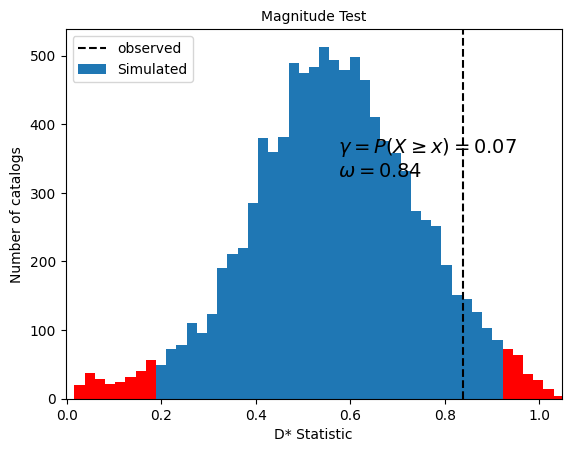

In [77]:
magnitude_test_result = catalog_tests.run_magnitude_test_result(
    result_dict=result_dict,
    obs_catalog_repr='obs',
   obs_name='observed',
    sim_name='Simulated',
    plot=False
)
magnitude_test_result.plot(plot_args={'figsize':(6.4,4.8),'tight_layout':False})
plt.savefig(checkpoint_dir/'m_test.pdf')

In [78]:
checkpoint_dir

PosixPath('../checkpoints/mixer_tpp_20260207-095619')